##Machine Learning | SIS 1

###Level A, Task 1.1

In [ ]:
import pandas as pd

df = pd.read_csv("LevelA.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Data loading and analyzing

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes
})

summary


,Column,Data Type
PassengerId,PassengerId,int64
Survived,Survived,int64
Pclass,Pclass,int64
Name,Name,object
Sex,Sex,object
Age,Age,float64
SibSp,SibSp,int64
Parch,Parch,int64
Ticket,Ticket,object
Fare,Fare,float64


####Examining the attributes by real world meaning and mesurement

###Task 1.2


In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df.head()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,892,0,3,34.5,0,0,7.8292
1,893,1,3,47.0,1,0,7.0000
2,894,0,2,62.0,0,0,9.6875
3,895,0,3,27.0,0,0,8.6625
4,896,1,3,22.0,1,1,12.2875


In [ ]:
stats = pd.DataFrame()

stats["mean"] = numeric_df.mean()
stats["median"] = numeric_df.median()
stats["mode"] = numeric_df.mode().iloc[0]
stats["range"] = numeric_df.max() - numeric_df.min()
stats["variance"] = numeric_df.var()
stats["std_dev"] = numeric_df.std()
stats["IQR"] = numeric_df.quantile(0.75) - numeric_df.quantile(0.25)


stats

,mean,median,mode,range,variance,std_dev,IQR
PassengerId,1100.500000,1100.5000,892.00,417.0000,14595.166667,120.810458,208.5000
Survived,0.363636,0.0000,0.00,1.0000,0.231960,0.481622,1.0000
Pclass,2.265550,3.0000,3.00,2.0000,0.708690,0.841838,2.0000
Age,30.272590,27.0000,21.00,75.8300,201.106695,14.181209,18.0000
SibSp,0.447368,0.0000,0.00,8.0000,0.804178,0.896760,1.0000
Parch,0.392344,0.0000,0.00,9.0000,0.963203,0.981429,0.0000
Fare,35.627188,14.4542,7.75,512.3292,3125.657074,55.907576,23.6042


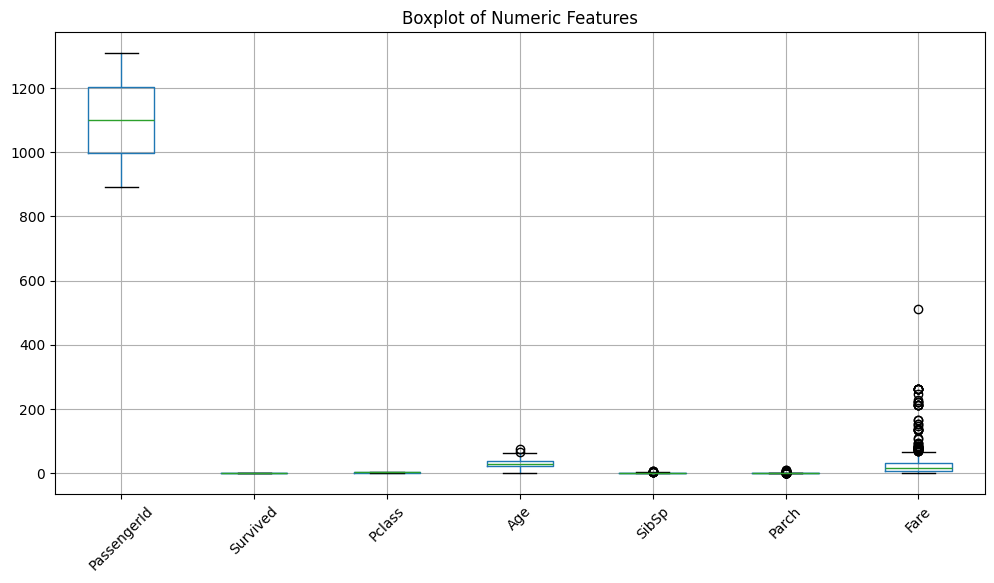

In [ ]:
import matplotlib.pyplot as plt

numeric_df.boxplot(figsize=(12,6))
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.show()


Boxplots were used to visually detect potential outliers.

In [ ]:
outliers = {}

for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers[col] = numeric_df[(numeric_df[col] < lower) | (numeric_df[col] > upper)][col].values
outliers

{'PassengerId': array([], dtype=int64),
 'Survived': array([], dtype=int64),
 'Pclass': array([], dtype=int64),
 'Age': array([67., 76.]),
 'SibSp': array([3, 4, 5, 3, 4, 8, 4, 8, 4, 3, 3]),
 'Parch': array([1, 1, 1, 1, 3, 1, 2, 2, 1, 2, 1, 2, 1, 2, 4, 1, 1, 2, 1, 1, 1, 4,
        6, 2, 3, 1, 1, 2, 2, 2, 1, 1, 2, 5, 2, 3, 2, 1, 1, 1, 2, 1, 2, 2,
        2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2,
        1, 1, 1, 2, 1, 2, 9, 1, 1, 1, 2, 2, 2, 1, 9, 1, 1, 2, 2, 1, 1, 2,
        1, 1, 1, 1, 1, 1]),
 'Fare': array([ 82.2667, 262.375 ,  76.2917, 263.    , 262.375 , 262.375 ,
        263.    , 211.5   , 211.5   , 221.7792,  78.85  , 221.7792,
         75.2417, 151.55  , 262.375 ,  83.1583, 221.7792,  83.1583,
         83.1583, 247.5208,  69.55  , 134.5   , 227.525 ,  73.5   ,
        164.8667, 211.5   ,  71.2833,  75.25  , 106.425 , 134.5   ,
        136.7792,  75.2417, 136.7792,  82.2667,  81.8583, 151.55  ,
         93.5   , 135.6333, 146.5208, 211.3375,  79.2   ,  6

I computed those boundaries explicitly so I can list the exact observations

### Rroblem 1.3
#### Here in this dataset, i have no missing values, so i will do it myself

In [ ]:
import numpy as np

df_missing = df.copy()
numeric_cols = df_missing.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    df_missing.loc[df_missing.sample(frac=0.05).index, col] = np.nan
# i made that way, so there will be 5% of them missing values and randomly selected
df_missing.isna().sum()


,0
PassengerId,21
Survived,21
Pclass,21
Name,0
Sex,0
Age,103
SibSp,21
Parch,21
Ticket,0
Fare,22


In [ ]:
original_stats = df[numeric_cols].agg(['mean','std']).T
original_stats


,mean,std
PassengerId,1100.500000,120.810458
Survived,0.363636,0.481622
Pclass,2.265550,0.841838
Age,30.272590,14.181209
SibSp,0.447368,0.896760
Parch,0.392344,0.981429
Fare,35.627188,55.907576


In [ ]:
constant_df = df_missing.fillna(0) # It is first imputation


In [ ]:
mean_df = df_missing.copy()
numeric_cols = mean_df.select_dtypes(include=['int64','float64']).columns
mean_df[numeric_cols] = mean_df[numeric_cols].fillna(mean_df[numeric_cols].mean()) #second imputation


Mean imputation is only for numeric data

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)
knn_df = pd.DataFrame(imputer.fit_transform(df_missing[numeric_cols]), columns=numeric_cols)


knn imputation predicts missing values based on similar observations

In [ ]:
constant_stats = constant_df[numeric_cols].agg(['mean','std']).T
mean_stats = mean_df[numeric_cols].agg(['mean','std']).T
knn_stats = knn_df.agg(['mean','std']).T

comparison = pd.concat([
    original_stats.add_suffix('_original'),
    constant_stats.add_suffix('_constant'),
    mean_stats.add_suffix('_mean'),
    knn_stats.add_suffix('_knn')
], axis=1)

comparison# here we did the comparison


,mean_original,std_original,mean_constant,std_constant,mean_mean,std_mean,mean_knn,std_knn
PassengerId,1100.500000,120.810458,1045.794258,268.067211,1101.113350,117.766320,1102.877990,118.771764
Survived,0.363636,0.481622,0.344498,0.475774,0.362720,0.469114,0.363636,0.472687
Pclass,2.265550,0.841838,2.143541,0.956346,2.256927,0.819126,2.268740,0.832222
Age,30.272590,14.181209,22.942775,18.061170,30.444698,12.396700,29.966164,13.539314
SibSp,0.447368,0.896760,0.421053,0.889446,0.443325,0.884146,0.442584,0.893786
Parch,0.392344,0.981429,0.377990,0.974836,0.397985,0.970943,0.393142,0.978525
Fare,35.627188,55.907576,34.038208,55.046974,35.929219,54.457767,34.770256,54.744037


Imputation is problematic, because it reduces variance and may artificially concentrate values around the mean